# ViT Multiple Pretrained Model Training

## Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import gc
import json
import joblib

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import CIFAR100
from torchvision.utils import make_grid
from torch.utils.data import DataLoader, Dataset
from torch.utils.data import random_split, ConcatDataset
from torchvision import transforms
from loguru import logger
import matplotlib.image as mpimg
from nazi_symbols_classification.training.data_preparation import get_image_paths, load_labels_df
from nazi_symbols_classification.training.torch_dataset_preparation import ImageData, get_device, to_device, ToDeviceLoader

from sklearn.preprocessing import LabelEncoder
from early_stopping_pytorch import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, roc_curve, auc

import timm

## Loading the Dataset

In [2]:
dir_name = os.path.dirname(os.getcwd())
dataset_path = f"{dir_name}/datasets/nazi-symbols-classification"

In [4]:
train_labels_df = load_labels_df(dataset_path, "train", binary=False)
valid_labels_df = load_labels_df(dataset_path, "val", binary=False)
test_labels_df = load_labels_df(dataset_path, "test", binary=False)

2025-06-13 01:46:54.247 | INFO     | __main__:load_labels_df:3 - Number of images in train is 9009
2025-06-13 01:46:54.277 | INFO     | __main__:load_labels_df:3 - Number of images in val is 1934
2025-06-13 01:46:54.294 | INFO     | __main__:load_labels_df:3 - Number of images in test is 1944


In [5]:
train_labels_df.head(5)

,path,nazi_cls
0,/home/zhiwei/Projects/nazi-symbols-classificat...,hitler_salute
1,/home/zhiwei/Projects/nazi-symbols-classificat...,hitler_salute
2,/home/zhiwei/Projects/nazi-symbols-classificat...,hitler_salute
3,/home/zhiwei/Projects/nazi-symbols-classificat...,hitler_salute
4,/home/zhiwei/Projects/nazi-symbols-classificat...,hitler_salute


## Data Preprocessing

In [6]:
remap_dict = {
    'nazi_cls': {
        "atomwaffen": "neo-nazi", 
        "blood_honor_emblem": "neo-nazi", 
        "celtic_cross": "neo-nazi", 
        "combat_18_emblem": "neo-nazi", 
        "golden_dawn": "neo-nazi", 
        "hammerskins": "neo-nazi", 
        "identitaere_bewegung_emblem": "neo-nazi", 
        "kolovrat": "neo-nazi", 
        "national_rebirth_poland": "neo-nazi", 
        "volksfront_emblem": "neo-nazi", 
        "doppelsiegrune": "siegrune"
    }
}
train_labels_df = train_labels_df.replace(remap_dict)
valid_labels_df = valid_labels_df.replace(remap_dict)
test_labels_df = test_labels_df.replace(remap_dict)

<Axes: xlabel='nazi_cls'>

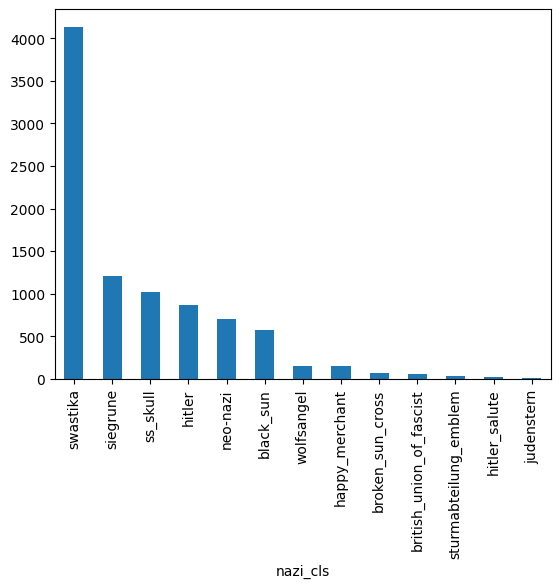

In [7]:
train_labels_df.nazi_cls.value_counts().plot(kind="bar")

<Axes: xlabel='nazi_cls'>

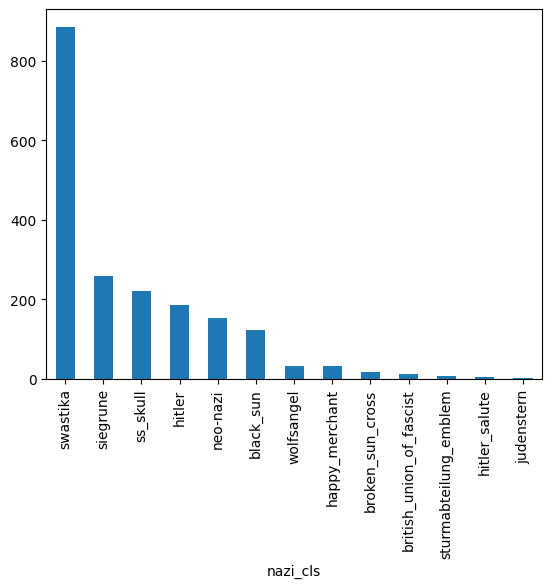

In [8]:
valid_labels_df.nazi_cls.value_counts().plot(kind="bar")

<Axes: xlabel='nazi_cls'>

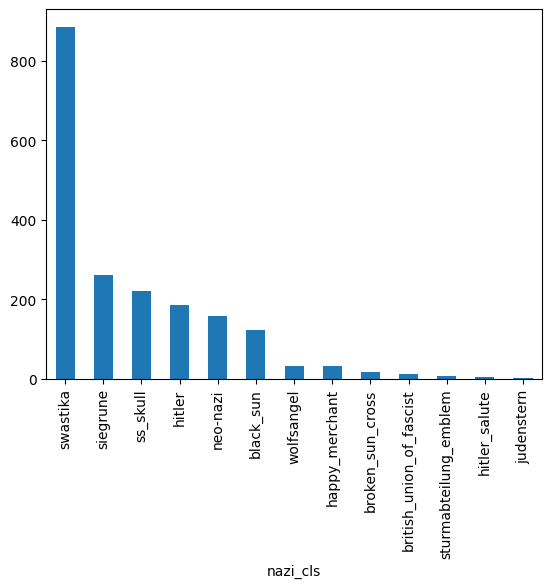

In [9]:
test_labels_df.nazi_cls.value_counts().plot(kind="bar")

## Encoding Labels

In [10]:
le = LabelEncoder()

le.fit(train_labels_df.nazi_cls)
train_labels_df["nazi_cls_encoded"] = le.transform(train_labels_df.nazi_cls)
valid_labels_df["nazi_cls_encoded"] = le.transform(valid_labels_df.nazi_cls)
test_labels_df["nazi_cls_encoded"] = le.transform(test_labels_df.nazi_cls)

## Data Transformation

In [12]:
IMG_SIZE = 224
stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
data_transf = transforms.Compose([transforms.ToPILImage(), 
                                  transforms.Grayscale(num_output_channels=3),
                                  transforms.Resize((IMG_SIZE, IMG_SIZE)), 
                                  transforms.ToTensor(),
                                  transforms.Normalize(*stats)])

def create_datasets(batch_size, dataset_path=dataset_path):
    train_data = ImageData(df = train_labels_df,
                           data_directory = os.path.join(dataset_path, 'train'),
                           transform = data_transf,
                           label_column = "nazi_cls_encoded")
    train_loader = DataLoader(dataset = train_data, batch_size = batch_size, shuffle=True)
    
    valid_data = ImageData(df = valid_labels_df, 
                           data_directory = os.path.join(dataset_path, 'val'), 
                           transform = data_transf,
                           label_column = "nazi_cls_encoded")
    valid_loader = DataLoader(dataset = valid_data, batch_size = batch_size, shuffle=False)

    test_data = ImageData(df = test_labels_df, 
                           data_directory = os.path.join(dataset_path, 'test'), 
                           transform = data_transf,
                           label_column = "nazi_cls_encoded")
    test_loader = DataLoader(dataset = test_data, batch_size = batch_size, shuffle=False)
    return train_loader, valid_loader, test_loader

In [13]:
batch_size = 16

train_loader, valid_loader, test_loader = create_datasets(batch_size, dataset_path)

In [15]:
device = get_device()
print(device)

train_dl = ToDeviceLoader(train_loader, device)
valid_dl = ToDeviceLoader(valid_loader, device)
test_dl = ToDeviceLoader(test_loader, device)

cuda


## Model Definition

In [16]:
print("Available Vision Transformer Models: ")
timm.list_models("vit*")

Available Vision Transformer Models: 


['vit_base_mci_224',
 'vit_base_patch8_224',
 'vit_base_patch14_dinov2',
 'vit_base_patch14_reg4_dinov2',
 'vit_base_patch16_18x2_224',
 'vit_base_patch16_224',
 'vit_base_patch16_224_miil',
 'vit_base_patch16_384',
 'vit_base_patch16_clip_224',
 'vit_base_patch16_clip_384',
 'vit_base_patch16_clip_quickgelu_224',
 'vit_base_patch16_gap_224',
 'vit_base_patch16_plus_240',
 'vit_base_patch16_plus_clip_240',
 'vit_base_patch16_reg4_gap_256',
 'vit_base_patch16_rope_reg1_gap_256',
 'vit_base_patch16_rpn_224',
 'vit_base_patch16_siglip_224',
 'vit_base_patch16_siglip_256',
 'vit_base_patch16_siglip_384',
 'vit_base_patch16_siglip_512',
 'vit_base_patch16_siglip_gap_224',
 'vit_base_patch16_siglip_gap_256',
 'vit_base_patch16_siglip_gap_384',
 'vit_base_patch16_siglip_gap_512',
 'vit_base_patch16_xp_224',
 'vit_base_patch32_224',
 'vit_base_patch32_384',
 'vit_base_patch32_clip_224',
 'vit_base_patch32_clip_256',
 'vit_base_patch32_clip_384',
 'vit_base_patch32_clip_448',
 'vit_base_patch32

In [17]:
class ViTBase16(nn.Module):
    def __init__(self, n_classes, pretrained=False):

        super(ViTBase16, self).__init__()

        self.model = timm.create_model("vit_base_patch16_224", pretrained=pretrained)

        self.model.head = nn.Linear(self.model.head.in_features, n_classes)

    def forward(self, x):
        x = self.model(x)
        return x

    def train_one_epoch(self, train_loader, criterion, optimizer):
        # keep track of training loss
        epoch_loss = 0.0
        epoch_accuracy = 0.0

        ###################
        # train the model #
        ###################
        self.model.train()
        for i, (data, target) in enumerate(train_loader):

            # clear the gradients of all optimized variables
            optimizer.zero_grad()
            # forward pass: compute predicted outputs by passing inputs to the model
            output = self.forward(data)
            # calculate the batch loss
            loss = criterion(output, target)
            # backward pass: compute gradient of the loss with respect to model parameters
            loss.backward()
            # Calculate Accuracy
            accuracy = (output.argmax(dim=1) == target).float().mean()
            # update training loss and accuracy
            epoch_loss += loss
            epoch_accuracy += accuracy

            # perform a single optimization step (parameter update)
            optimizer.step()

        return epoch_loss / len(train_loader), epoch_accuracy / len(train_loader)

    def validate_one_epoch(self, valid_loader, criterion):
        # keep track of validation loss
        valid_loss = 0.0
        valid_accuracy = 0.0

        ######################
        # validate the model #
        ######################
        self.model.eval()
        for data, target in valid_loader:

            with torch.no_grad():
                # forward pass: compute predicted outputs by passing inputs to the model
                output = self.model(data)
                # calculate the batch loss
                loss = criterion(output, target)
                # Calculate Accuracy
                accuracy = (output.argmax(dim=1) == target).float().mean()
                # update average validation loss and accuracy
                valid_loss += loss
                valid_accuracy += accuracy

        return valid_loss / len(valid_loader), valid_accuracy / len(valid_loader)

In [18]:

def fit(model, epochs, criterion, optimizer, train_loader, valid_loader, patience=10):
    # torch.cuda.empty_cache()
    
    # keeping track of losses as it happen
    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []

    early_stopping = EarlyStopping(patience=patience, verbose=True, path="vit-output/ViT-multiple-pretrained-size-224-batch-16.pt")
    
    for epoch in range(epochs):
        gc.collect()
        
        print(f"{'='*50}")
        print(f"EPOCH {epoch} - TRAINING...")
        train_loss, train_acc = model.train_one_epoch(
            train_loader, criterion, optimizer
        )
        print(
            f"\n\t[TRAIN] EPOCH {epoch} - LOSS: {train_loss}, ACCURACY: {train_acc}\n"
        )
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        gc.collect()

        
        print(f"EPOCH {epoch} - VALIDATING...")
        valid_loss, valid_acc = model.validate_one_epoch(
            valid_loader, criterion
        )
        print(f"\t[VALID] LOSS: {valid_loss}, ACCURACY: {valid_acc}\n")
        valid_losses.append(valid_loss)
        valid_accs.append(valid_acc)
        gc.collect()

        early_stopping(valid_loss.item(), model)
        
        if early_stopping.early_stop:
            print("Early stopping")
            break
        
    return {
        "train_loss": train_losses,
        "valid_losses": valid_losses,
        "train_acc": train_accs,
        "valid_acc": valid_accs,
    }

## Training the Model

In [19]:
# model specific global variables
epochs = 100
patience = 10

model = ViTBase16(n_classes=13, pretrained=True)
model = to_device(model, device)
criterion = nn.CrossEntropyLoss()
lr = 2e-05
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [19]:
%%time
history = fit(model=model, epochs=epochs, criterion=criterion, optimizer=optimizer,
              train_loader=train_dl, valid_loader=valid_dl,patience=patience)

EPOCH 0 - TRAINING...

	[TRAIN] EPOCH 0 - LOSS: 0.5858073234558105, ACCURACY: 0.804964542388916

EPOCH 0 - VALIDATING...
	[VALID] LOSS: 0.42883092164993286, ACCURACY: 0.857806921005249

Validation loss decreased (inf --> 0.428831).  Saving model ...
EPOCH 1 - TRAINING...

	[TRAIN] EPOCH 1 - LOSS: 0.2925305664539337, ACCURACY: 0.8833111524581909

EPOCH 1 - VALIDATING...
	[VALID] LOSS: 0.288239449262619, ACCURACY: 0.8803128600120544

Validation loss decreased (0.428831 --> 0.288239).  Saving model ...
EPOCH 2 - TRAINING...

	[TRAIN] EPOCH 2 - LOSS: 0.2362186312675476, ACCURACY: 0.8916223049163818

EPOCH 2 - VALIDATING...
	[VALID] LOSS: 0.3264611065387726, ACCURACY: 0.8690229654312134

EarlyStopping counter: 1 out of 10
EPOCH 3 - TRAINING...

	[TRAIN] EPOCH 3 - LOSS: 0.21912173926830292, ACCURACY: 0.901374101638794

EPOCH 3 - VALIDATING...
	[VALID] LOSS: 0.2957538366317749, ACCURACY: 0.8695394992828369

EarlyStopping counter: 2 out of 10
EPOCH 4 - TRAINING...

	[TRAIN] EPOCH 4 - LOSS: 0.2

In [21]:
history_temp = dict()
for k, vl in history.items():
    history_temp[k] = []
    for item in vl:
        history_temp[k].append(item.item())
history = history_temp

In [22]:
import json

with open('vit-output/ViT-multiple-history.json', 'w') as f:
    f.write(json.dumps(history))

## Evaluating the Model

In [20]:
model.load_state_dict(torch.load("vit-output/ViT-multiple-pretrained-size-224-batch-16.pt", weights_only=True))
model.eval()

ViTBase16(
  (model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
  

In [21]:
outputs = []
y_true = []
for batch in test_dl:
    images, labels = batch
    images, labels = images, labels
    with torch.no_grad():
        out = model(images)
    _, predicted = torch.max(out, 1)
    # print([le.classes_[predicted[i]] for i in range(len(images))])
    y_true += labels.cpu()
    outputs += predicted.cpu()

## Classification Report and Accuracy

In [22]:
print(classification_report(y_true, outputs, digits=3))
accuracy_score(y_true, outputs)

              precision    recall  f1-score   support

           0      0.862     0.855     0.858       124
           1      1.000     0.917     0.957        12
           2      1.000     0.375     0.545        16
           3      1.000     1.000     1.000        33
           4      0.822     0.946     0.879       185
           5      0.000     0.000     0.000         5
           6      1.000     1.000     1.000         3
           7      0.894     0.797     0.843       158
           8      0.789     0.862     0.824       261
           9      0.729     0.855     0.787       220
          10      1.000     0.750     0.857         8
          11      0.961     0.900     0.929       886
          12      0.771     0.818     0.794        33

    accuracy                          0.876      1944
   macro avg      0.833     0.775     0.790      1944
weighted avg      0.883     0.876     0.876      1944



0.8760288065843621

In [23]:
le.classes_

array(['black_sun', 'british_union_of_fascist', 'broken_sun_cross',
       'happy_merchant', 'hitler', 'hitler_salute', 'judenstern',
       'neo-nazi', 'siegrune', 'ss_skull', 'sturmabteilung_emblem',
       'swastika', 'wolfsangel'], dtype=object)

In [24]:
predicted_result = dict(y_true=y_true, outputs=outputs)
joblib.dump(predicted_result, "vit-output/vit-multiple-predicted-result.joblib")

['vit-multiple-predicted-result.joblib']